In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [ ]:
# Load the dataset
file_path = "/content/transaction_history.csv"
df = pd.read_csv(file_path)

# Display first few rows
print(df.head())


   customer_id transaction_date  transaction_amount transaction_type  \
0            1          42:46.4                6775          deposit   
1            3          16:42.0                2589       withdrawal   
2            3          06:09.3                1902       withdrawal   
3            4          04:05.9                7292       withdrawal   
4            4          37:53.8                6175          payment   

  transaction_description  
0          Salary Deposit  
1          ATM Withdrawal  
2            Bill Payment  
3         Online Transfer  
4         Restaurant Bill  


In [ ]:
# Convert transaction_date to datetime format
df["transaction_date"] = pd.to_datetime(df["transaction_date"], errors="coerce")

# Drop rows where transaction_date is NaT
df = df.dropna(subset=['transaction_date'])

# Sort data by customer_id and transaction_date
df = df.sort_values(["customer_id", "transaction_date"])

# Display the first few rows
print(df.head())

   customer_id    transaction_date  transaction_amount transaction_type  \
2            3 2025-04-02 06:09:18                1902       withdrawal   
1            3 2025-04-02 16:42:00                2589       withdrawal   
3            4 2025-04-02 04:05:54                7292       withdrawal   
6            4 2025-04-02 12:01:36                7012          deposit   
7            5 2025-04-02 03:25:36                 465          deposit   

  transaction_description  
2            Bill Payment  
1          ATM Withdrawal  
3         Online Transfer  
6          Salary Deposit  
7           Check Deposit  


<ipython-input-4-8e599eb1d687>:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["transaction_date"] = pd.to_datetime(df["transaction_date"], errors="coerce")


In [ ]:
# Compute the rolling transaction count for the last 7 days
df['transaction_count_7d'] = df.groupby("customer_id").apply(
    lambda g: g.rolling("7D", on='transaction_date', min_periods=1)['transaction_amount'].count()
).reset_index(drop=True)

<ipython-input-5-c57f15b6fbc3>:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df['transaction_count_7d'] = df.groupby("customer_id").apply(


In [ ]:
#Calculate the days since the last transaction for each customer.
df["days_since_last_txn"] = df.groupby("customer_id")["transaction_date"].diff().dt.days.fillna(0)


In [ ]:
#Transaction Variance (Standard Deviation of Amount)
df["txn_std_30d"] = df.groupby("customer_id")["transaction_amount"].transform(lambda x: x.rolling(30, min_periods=1).std().fillna(0))


In [ ]:
# Rolling mean for the last 7 and 30 days within each customer group
df['txn_mean_7d'] = df.groupby("customer_id")['transaction_amount'].transform(
    lambda x: x.rolling(window=7, min_periods=1).mean()
)

df['txn_mean_30d'] = df.groupby("customer_id")['transaction_amount'].transform(
    lambda x: x.rolling(window=30, min_periods=1).mean()
)

In [ ]:
#Ratio of Transaction Amount to Customer’s Mean
df["customer_mean_txn"] = df.groupby("customer_id")["transaction_amount"].transform("mean")
df["txn_ratio"] = df["transaction_amount"] / df["customer_mean_txn"]


In [ ]:
df.columns

Index(['customer_id', 'transaction_date', 'transaction_amount',
       'transaction_type', 'transaction_description', 'transaction_count_7d',
       'days_since_last_txn', 'txn_std_30d', 'txn_mean_7d', 'txn_mean_30d',
       'customer_mean_txn', 'txn_ratio'],
      dtype='object')

In [ ]:
df.head()

,customer_id,transaction_date,transaction_amount,transaction_type,transaction_description,transaction_count_7d,days_since_last_txn,txn_std_30d,txn_mean_7d,txn_mean_30d,customer_mean_txn,txn_ratio
2,3,2025-04-02 06:09:18,1902,withdrawal,Bill Payment,1.0,0.0,0.000000,1902.0,1902.0,2245.5,0.847027
1,3,2025-04-02 16:42:00,2589,withdrawal,ATM Withdrawal,2.0,0.0,485.782359,2245.5,2245.5,2245.5,1.152973
3,4,2025-04-02 04:05:54,7292,withdrawal,Online Transfer,2.0,0.0,0.000000,7292.0,7292.0,7152.0,1.019575
6,4,2025-04-02 12:01:36,7012,deposit,Salary Deposit,1.0,0.0,197.989899,7152.0,7152.0,7152.0,0.980425
7,5,2025-04-02 03:25:36,465,deposit,Check Deposit,1.0,0.0,0.000000,465.0,465.0,465.0,1.000000


In [ ]:
# Assuming these encoders were used in training
transaction_type_encoder = LabelEncoder()
transaction_description_encoder = LabelEncoder()

# Fit encoders on original training data (if not saved)
transaction_type_encoder.fit(df["transaction_type"])
transaction_description_encoder.fit(df["transaction_description"])

# Get class mappings
transaction_type_mapping = dict(zip(transaction_type_encoder.classes_, transaction_type_encoder.transform(transaction_type_encoder.classes_)))
transaction_description_mapping = dict(zip(transaction_description_encoder.classes_, transaction_description_encoder.transform(transaction_description_encoder.classes_)))

print("Transaction Type Mapping:", transaction_type_mapping)
print("Transaction Description Mapping:", transaction_description_mapping)

# Create the encoded columns in your DataFrame
df["transaction_type_encoded"] = transaction_type_encoder.transform(df["transaction_type"])
df["transaction_description_encoded"] = transaction_description_encoder.transform(df["transaction_description"])

Transaction Type Mapping: {'deposit': np.int64(0), 'payment': np.int64(1), 'withdrawal': np.int64(2)}
Transaction Description Mapping: {'ATM Withdrawal': np.int64(0), 'Bill Payment': np.int64(1), 'Cash Deposit': np.int64(2), 'Check Deposit': np.int64(3), 'Grocery Shopping': np.int64(4), 'Online Purchase': np.int64(5), 'Online Transfer': np.int64(6), 'Restaurant Bill': np.int64(7), 'Salary Deposit': np.int64(8)}


In [ ]:
# Select features to be used for Isolation Forest
features = ["transaction_amount", "transaction_type_encoded", "transaction_description_encoded",
            "transaction_count_7d", "days_since_last_txn", "txn_std_30d", "txn_mean_7d", "txn_mean_30d", "txn_ratio"]
df_features = df[features].fillna(0)  # Fill NaN values



In [ ]:
from sklearn.model_selection import train_test_split
# Split dataset into training and testing sets (Isolation Forest is unsupervised)
X_train, X_test = train_test_split(df_features, test_size=0.2, random_state=42)

In [ ]:
# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the Isolation Forest Model
iso_forest = IsolationForest(contamination=0.05, random_state=42)
iso_forest.fit(X_train_scaled)

IsolationForest(contamination=0.05, random_state=42)

In [ ]:
# Predict anomaly scores and labels
df["anomaly_score"] = iso_forest.decision_function(scaler.transform(df_features))
df["anomaly"] = iso_forest.predict(scaler.transform(df_features))  # -1 for anomaly, 1 for normal

# Count total anomalies
num_anomalies = (df["anomaly"] == -1).sum()
print(f"Total Anomalies Detected: {num_anomalies}")

# Extract only anomalous transactions
anomalies = df[df["anomaly"] == -1]

# Save anomalies to a file (optional)
anomalies.to_csv("detected_anomalies.csv", index=False)
print("Anomalies saved to detected_anomalies.csv")

Total Anomalies Detected: 99
Anomalies saved to detected_anomalies.csv


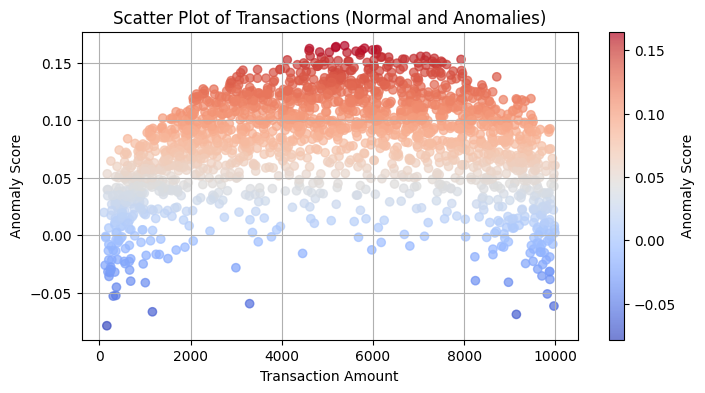

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.scatter(df["transaction_amount"], df["anomaly_score"], c=df["anomaly_score"], cmap="coolwarm", alpha=0.7)
plt.title("Scatter Plot of Transactions (Normal and Anomalies)")
plt.xlabel("Transaction Amount")
plt.ylabel("Anomaly Score")
plt.colorbar(label="Anomaly Score")
plt.grid(True)
plt.show()


In [ ]:
#anomaly_scores_test = iso_forest.decision_function(X_test)
anomaly_predictions_test = iso_forest.predict(X_test_scaled)

#print("Anomaly Scores:", anomaly_scores_test)
print("Anomaly Predictions:", anomaly_predictions_test)


Anomaly Predictions: [ 1  1  1  1 -1  1  1 -1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1 -1
  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1 -1  1  1  1  1  1 -1  1  1
  1  1  1  1  1 -1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1 -1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1 -1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1
  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1
 -1  1  1  1  1  1  1  1  1  1

In [ ]:
import pandas as pd

# Convert to Pandas Series (if it's not already)
anomaly_series = pd.Series(anomaly_predictions_test)

# Count values
counts = anomaly_series.value_counts()
print(counts)


 1    350
-1     24
Name: count, dtype: int64


In [ ]:
# Ensure X_test_scaled has the same number of rows as X_test
anomaly_scores_test = iso_forest.decision_function(X_test_scaled)
anomaly_predictions_test = iso_forest.predict(X_test_scaled)

# Create a new DataFrame for test data results
df_test_results = X_test.copy()  # Copy test features
df_test_results["anomaly_score"] = anomaly_scores_test
df_test_results["anomaly"] = anomaly_predictions_test  # -1 for anomaly, 1 for normal

# Print the count of anomalies
print(df_test_results["anomaly"].value_counts())  # Shows count of 1s and -1s

# (Optional) Save test anomalies to a CSV
df_test_results[df_test_results["anomaly"] == -1].to_csv("test_detected_anomalies.csv", index=False)
print("Test anomalies saved to test_detected_anomalies.csv")


anomaly
 1    350
-1     24
Name: count, dtype: int64
Test anomalies saved to test_detected_anomalies.csv


In [ ]:
import pandas as pd

new_transaction = pd.DataFrame({
    "transaction_amount": [2000.0],
    "transaction_type_encoded": [0],
    "transaction_description_encoded": [1],
    'transaction_count_7d': [1],
    "days_since_last_txn": [3],
    'txn_std_30d': [0.0],
    "txn_mean_7d": [127.0],
    "txn_mean_30d": [127.0],
    "txn_ratio": [0.05],

})


In [ ]:
print("Features used in training:", scaler.feature_names_in_)  # Check features used during training
print("Features in new transaction:", new_transaction.columns)  # Check features in new data


Features used in training: ['transaction_amount' 'transaction_type_encoded'
 'transaction_description_encoded' 'transaction_count_7d'
 'days_since_last_txn' 'txn_std_30d' 'txn_mean_7d' 'txn_mean_30d'
 'txn_ratio']
Features in new transaction: Index(['transaction_amount', 'transaction_type_encoded',
       'transaction_description_encoded', 'transaction_count_7d',
       'days_since_last_txn', 'txn_std_30d', 'txn_mean_7d', 'txn_mean_30d',
       'txn_ratio'],
      dtype='object')


In [ ]:
new_transaction_scaled = scaler.transform(new_transaction)  # Use the same scaler from training


In [ ]:
# Predict anomaly (-1 for anomaly, 1 for normal)
prediction = iso_forest.predict(new_transaction_scaled)

if prediction[0] == -1:
    print("🚨 ALERT: The transaction is **anomalous**!")
else:
    print("✅ The transaction is normal.")


🚨 ALERT: The transaction is **anomalous**!


In [ ]:
import joblib

In [ ]:
joblib.dump(iso_forest, "isoforest_model.pkl")

['isoforest_model.pkl']

In [ ]:
df[features].describe()


,transaction_amount,transaction_type_encoded,transaction_description_encoded,transaction_count_7d,days_since_last_txn,txn_std_30d,txn_mean_7d,txn_mean_30d,txn_ratio
count,1867.000000,1867.000000,1867.000000,765.000000,1867.0,1867.000000,1867.000000,1867.000000,1867.000000
mean,5116.870916,1.004285,3.944831,2.159477,0.0,1477.199382,5104.289851,5104.289851,1.000000
std,2881.910986,0.805915,2.548071,1.263950,0.0,1612.121936,2331.662646,2331.662646,0.481570
min,104.000000,0.000000,0.000000,1.000000,0.0,0.000000,127.000000,127.000000,0.034479
25%,2579.500000,0.000000,2.000000,1.000000,0.0,0.000000,3465.791667,3465.791667,0.686896
50%,5174.000000,1.000000,4.000000,2.000000,0.0,987.121067,5114.500000,5114.500000,1.000000
75%,7610.500000,2.000000,6.000000,3.000000,0.0,2758.733072,6759.250000,6759.250000,1.268283
max,9993.000000,2.000000,8.000000,7.000000,0.0,6687.815936,9991.000000,9991.000000,2.812392


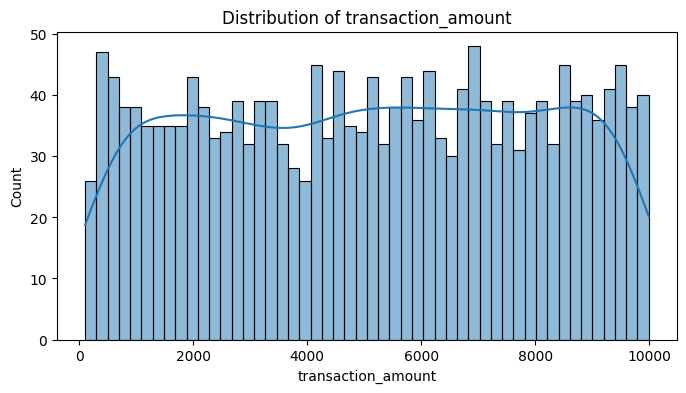

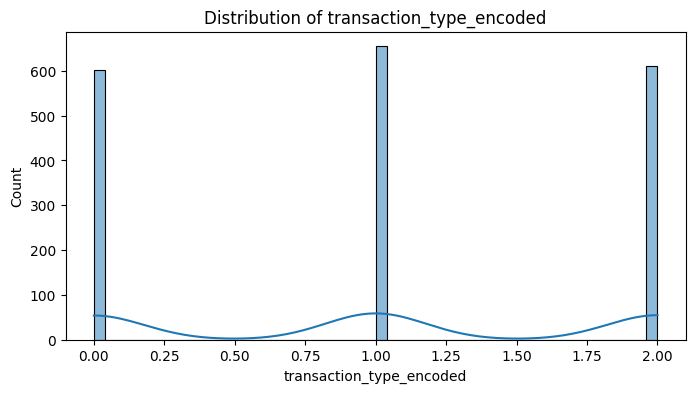

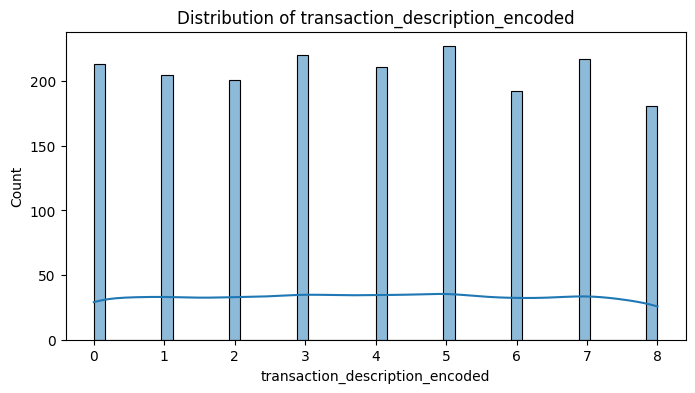

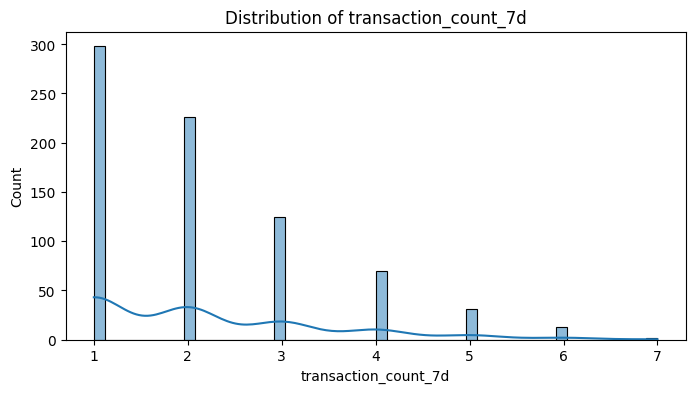

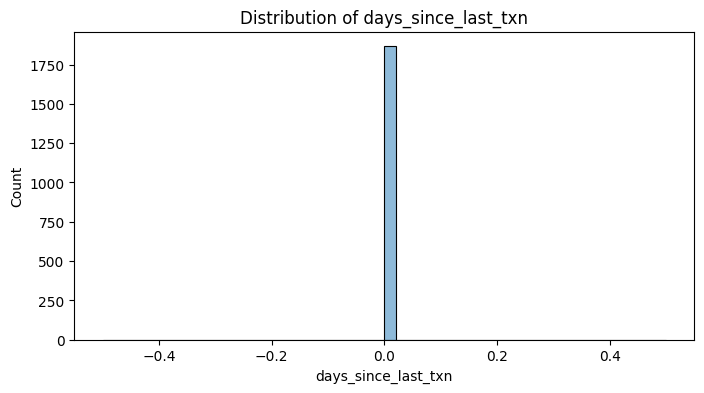

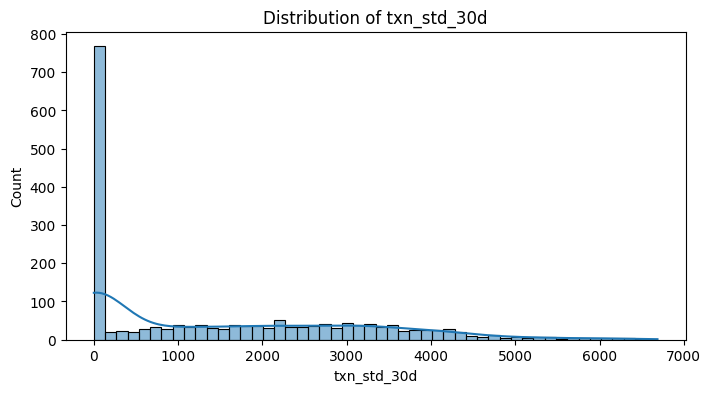

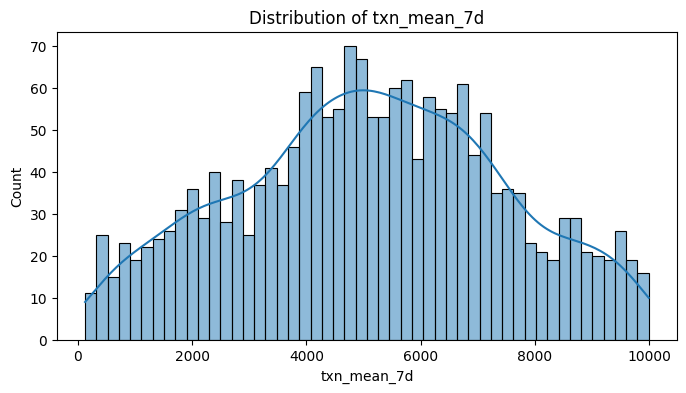

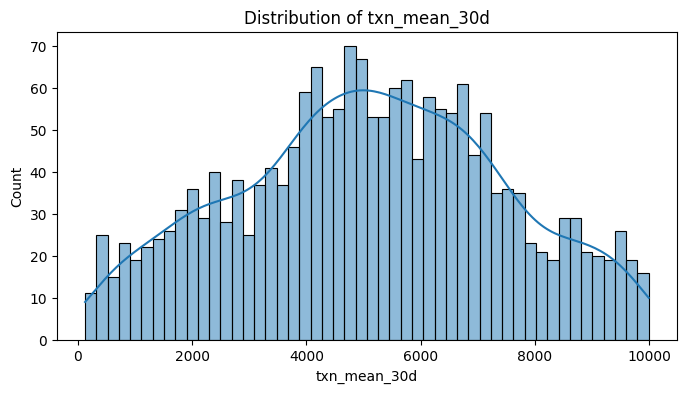

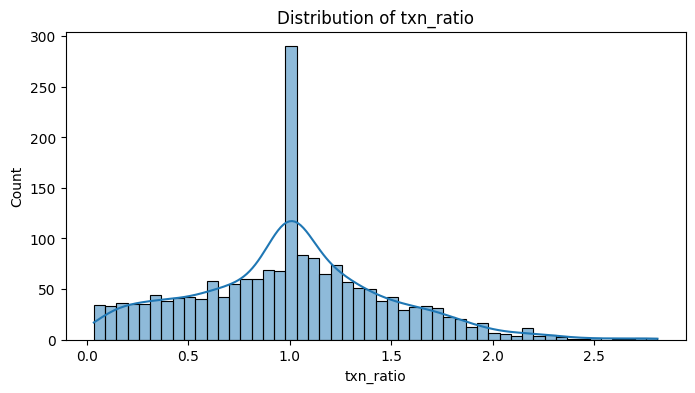

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

for feature in features:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[feature], bins=50, kde=True)
    plt.title(f"Distribution of {feature}")
    plt.show()


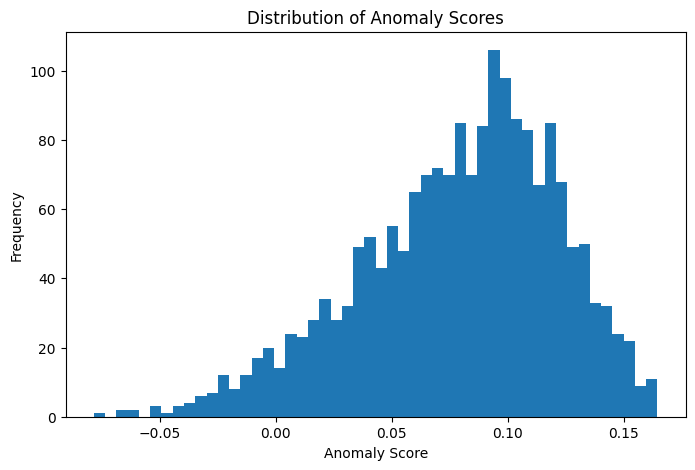

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df['anomaly_score'], bins=50)
plt.title('Distribution of Anomaly Scores')
plt.xlabel('Anomaly Score')
plt.ylabel('Frequency')
plt.show()

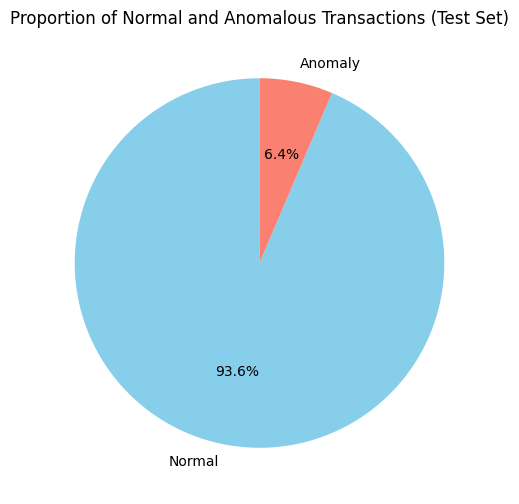

In [ ]:
import matplotlib.pyplot as plt

# Assuming df_test_results is your DataFrame with test results
anomaly_counts_test = df_test_results['anomaly'].value_counts()

# Create the pie chart
plt.figure(figsize=(6, 6))
plt.pie(anomaly_counts_test, labels=['Normal', 'Anomaly'], autopct='%1.1f%%', startangle=90, colors=['skyblue', 'salmon'])
plt.title('Proportion of Normal and Anomalous Transactions (Test Set)')
plt.show()

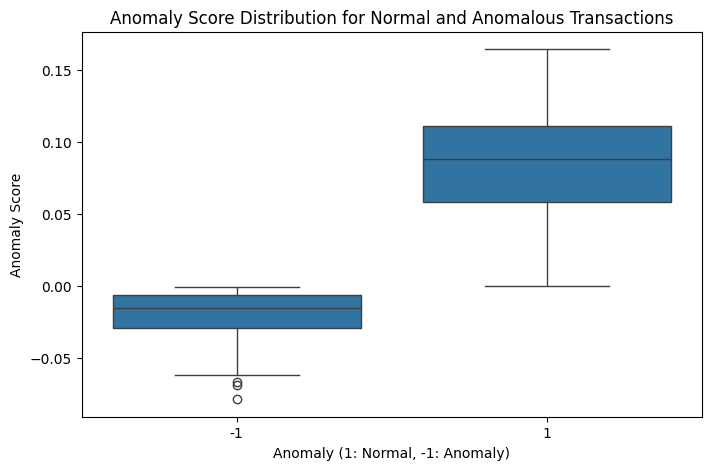

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.boxplot(x='anomaly', y='anomaly_score', data=df)
plt.title('Anomaly Score Distribution for Normal and Anomalous Transactions')
plt.xlabel('Anomaly (1: Normal, -1: Anomaly)')
plt.ylabel('Anomaly Score')
plt.show()